# Phase 0b — OpenFold on calmodulin

Second protein. Ubiquitin gave four findings; this notebook asks whether they survive a
protein with a genuinely different architecture.

**Why calmodulin.** 148 residues, two rigid globular lobes joined by a flexible central
helix. Deep MSA, extremely well studied. The two-domain structure means a question
ubiquitin could not ask: *do intra-domain and inter-domain contacts commit on different
schedules?* If they do, that connects the commitment story directly to PAE.

### What we are testing

| # | Ubiquitin finding | Does it generalize? |
|---|---|---|
| 1 | Long-range contacts predicted correctly at block 1, recycle 1 | |
| 2 | Precision flat near 1.0 while recall climbs 0.03 to 0.95 | |
| 3 | Oscillation in P(contact), not a threshold artifact | |
| 4 | Commitment step flat vs sequence separation | |
| 5 | Recycling has almost no effect | |

Plus one new question: **does the inter-lobe arrangement ever commit?**

### Fixes already baked in

Every trap hit in the ubiquitin notebook is pre-fixed here:
- Reference contacts built from **C-beta**, not C-alpha (AF2's distogram is C-beta based;
  using C-alpha cost 20 points of precision)
- `remove_leading_feature_dimension=False` in `from_prediction`
- Assert on `len(common)` so a failed residue-number match cannot pass silently
- Contact defined as **probability mass below 8 A**, not `E[d] < 8` (the catch-all 64th bin
  biases the expectation upward)
- Consistency assert tying precision, recall and counts together

## 0. Environment check

Same as the ubiquitin notebook. Confirms torch, CUDA, OpenFold and the custom attention
kernel are all importable before anything else runs.

In [1]:
import os, sys, json, pathlib, time
import numpy as np
import torch
import matplotlib.pyplot as plt

print("python     ", sys.version.split()[0])
print("torch      ", torch.__version__)
print("cuda avail ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device     ", torch.cuda.get_device_name(0))
    print("vram (GB)  ", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

import openfold
print("openfold   ", pathlib.Path(openfold.__file__).parent)
import attn_core_inplace_cuda
print("cuda kernel  OK")

python      3.10.20
torch       2.14.0+cu130
cuda avail  True
device      NVIDIA GeForce RTX 4060 Laptop GPU
vram (GB)   8.2
openfold    /home/caitlinlewis/repos/openfold/openfold
cuda kernel  OK


## 1. Configuration

**Numbering, and why the sequence starts at A rather than M.**

UniProt P0DP23 is 149 residues including the initiator methionine. The mature protein has
that Met removed and is 148 residues. PDB 1CLL numbers the mature protein 1-148.

If you predict the 149-mer, every predicted residue is offset by one from 1CLL and the
residue-number intersection silently produces garbage — the same failure mode that gave a
1x1 contact map on ubiquitin. Using the mature 148-residue sequence makes predicted
numbering line up with 1CLL directly.

**Unlike ubiquitin, calmodulin has a clean AFDB entry** (AF-P0DP23-F1), so an
AlphaFold-vs-AlphaFold comparison is available if you want it — just remember it covers the
149-mer.

**Lobe boundaries** below are approximate and taken from the standard description: an
N-lobe, a flexible central linker, and a C-lobe, with four EF-hand calcium-binding motifs.
They are used only for grouping contacts, so rough is fine — but check them against the
structure before putting numbers in the post.

In [1]:
SEQUENCE = (
    "ADQLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAELQDMINEVDADGNGTIDFPEFLTMMAR"
    "KMKDQDSEEEIREAFRVFDKDGNGYISAAELRHVMTNLGEKLTDEEVDEMIREADIDGDGQVNYEEFVQMMTAK"
)
NAME = "calmodulin"
L = len(SEQUENCE)
assert L == 148, L
print("length:", L)

MODEL_NAME = "model_3_ptm"

# approximate lobe boundaries, 1-based residue numbers (inclusive)
N_LOBE   = (1, 75)
LINKER   = (76, 81)
C_LOBE   = (82, 148)
EF_HANDS = [(20, 31), (56, 67), (93, 104), (129, 140)]

OPENFOLD_DIR = pathlib.Path(os.environ.get("OPENFOLD_DIR", "~/repos/openfold")).expanduser()
PARAMS_PATH  = OPENFOLD_DIR / "openfold" / "resources" / "params" / f"params_{MODEL_NAME}.npz"

WORK = pathlib.Path("./work").resolve()
for sub in ["fasta", f"alignments/{NAME}", "out", "ref", "curves"]:
    (WORK / sub).mkdir(parents=True, exist_ok=True)

FASTA_PATH    = WORK / "fasta" / f"{NAME}.fasta"
ALIGNMENT_DIR = WORK / "alignments"
A3M_PATH      = WORK / "alignments" / NAME / "mmseqs.a3m"
FASTA_PATH.write_text(f">{NAME}\n{SEQUENCE}\n")

print("params exists:", PARAMS_PATH.exists())
print(f"pair rep, one block fp32: {L**2 * 128 * 4 / 1e6:.1f} MB")
print(f"full (4, 48, {L}, {L}, 128): {L**2 * 128 * 4 * 48 * 4 / 1e9:.2f} GB")

length: 148


NameError: name 'pathlib' is not defined

## 2. MSA from the ColabFold MMseqs2 server

Cached to disk so reruns do not re-query the public server. Calmodulin is one of the most
conserved eukaryotic proteins, so expect a very deep alignment — deeper than ubiquitin's.

In [3]:
if not A3M_PATH.exists():
    from colabfold.colabfold import run_mmseqs2
    res = run_mmseqs2(
        SEQUENCE,
        prefix=str(WORK / "mmseqs_cache_cam"),
        use_env=True,
        use_filter=True,
        use_templates=False,
    )
    a3m_lines = res[0] if isinstance(res, (list, tuple)) else res
    A3M_PATH.write_text(a3m_lines)

a3m_text = A3M_PATH.read_text()
n_seqs = a3m_text.count(">")
print(f"MSA depth: {n_seqs} sequences   ({len(a3m_text)/1e6:.2f} MB)")
assert n_seqs > 100, "MSA suspiciously shallow"

# record it — MSA depth is the strongest predictor of AF2 accuracy and belongs
# in any cross-protein comparison
MSA_DEPTH = n_seqs

No user agent specified. Please set a user agent (e.g., 'toolname/version contact@email') to help us debug in case of problems. This warning will become an error in the future.
COMPLETE: 100%|████████████████████████████| 150/150 [elapsed: 01:15 remaining: 00:00]

MSA depth: 21362 sequences   (4.55 MB)


## 3. Feature dict

`DataPipeline.process_fasta` globs the per-target alignment directory for `.a3m`/`.sto`
files, so one `mmseqs.a3m` is enough. `template_featurizer=None` because `model_3_ptm`
does not consume templates.

In [4]:
from openfold.config import model_config
from openfold.data import data_pipeline, feature_pipeline

config = model_config(MODEL_NAME)
N_BLK = config.model.evoformer_stack.no_blocks
C_Z   = config.model.evoformer_stack.c_z
N_REC = config.data.common.max_recycling_iters + 1
print(f"blocks {N_BLK}  c_z {C_Z}  recycles {N_REC}")

dp = data_pipeline.DataPipeline(template_featurizer=None)
feature_dict = dp.process_fasta(
    fasta_path=str(FASTA_PATH),
    alignment_dir=str(ALIGNMENT_DIR / NAME),
)
fp = feature_pipeline.FeaturePipeline(config.data)
processed = fp.process_features(feature_dict, mode="predict")
print("aatype:", tuple(processed["aatype"].shape))

blocks 48  c_z 128  recycles 4


/home/caitlinlewis/repos/openfold/openfold/data/data_transforms.py:1261: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:356.)
  protein[k] = v[slices]


aatype: (148, 4)


## 4. Load weights, run inference

`import_jax_weights_` loads DeepMind's original AF2 parameters into the PyTorch module.
The `version` string must match the params filename exactly.

In [5]:
from openfold.model.model import AlphaFold
from openfold.utils.import_weights import import_jax_weights_
from openfold.utils.tensor_utils import tensor_tree_map

device = "cuda" if torch.cuda.is_available() else "cpu"
model = AlphaFold(config)
model.eval()
import_jax_weights_(model, str(PARAMS_PATH), version=MODEL_NAME)
model = model.to(device)

batch = {k: torch.as_tensor(v, device=device) for k, v in processed.items()}

t0 = time.time()
with torch.no_grad():
    out_t = model(batch)
print(f"inference: {time.time() - t0:.1f} s")
out = tensor_tree_map(lambda x: x.detach().cpu().numpy(), out_t)
del out_t
print("final_atom_positions:", out["final_atom_positions"].shape)

W0912 15:05:46.921000 54035 torch/fx/_symbolic_trace.py:57] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
[W912 15:05:47.895608912 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 1438646272 bytes (free: 907411456, total: 8186822656).
[W912 15:05:47.911433764 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 1438646272 bytes (free: 1047920640, total: 8186822656).
/home/caitlinlewis/repos/openfold/openfold/model/triangular_multiplicative_update.py:373: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result eith

inference: 33.3 s
final_atom_positions: (148, 37, 3)


## 5. Confidence — and the first real difference from ubiquitin

pLDDT should be high across both lobes. **PAE is the interesting panel here.** Expect two
dark blocks on the diagonal (the two lobes, each internally confident) with a brighter
off-diagonal region between them — the model knows each lobe but is less sure how they sit
relative to each other.

If that block structure is visible, the inter-lobe commitment question in section 10 has a
real answer waiting.

One caveat on the reference: **1CLL is the calcium-bound, extended-dumbbell crystal form.**
Calmodulin in solution samples much more compact arrangements, and the central helix is
known to be flexible. So "disagreement in the linker" is not necessarily model error.

mean pLDDT 83.7   min 40.9 at residue 148
N-lobe mean pLDDT 83.3
linker mean pLDDT 63.4
C-lobe mean pLDDT 85.9


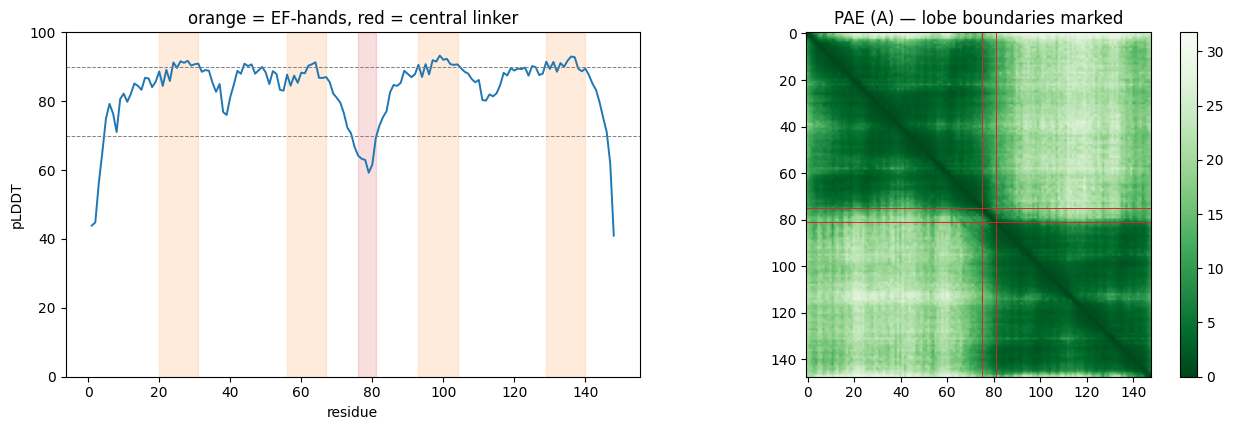


mean PAE within N-lobe : 5.2 A
mean PAE within C-lobe : 4.1 A
mean PAE N-lobe to C-lobe: 19.7 A   <- the interesting one


In [6]:
plddt = out["plddt"]
pae   = out.get("predicted_aligned_error")
ptm   = float(out["predicted_tm_score"]) if "predicted_tm_score" in out else None

print(f"mean pLDDT {plddt.mean():.1f}   min {plddt.min():.1f} at residue {int(plddt.argmin())+1}")
if ptm is not None:
    print(f"pTM {ptm:.3f}")
print(f"N-lobe mean pLDDT {plddt[N_LOBE[0]-1:N_LOBE[1]].mean():.1f}")
print(f"linker mean pLDDT {plddt[LINKER[0]-1:LINKER[1]].mean():.1f}")
print(f"C-lobe mean pLDDT {plddt[C_LOBE[0]-1:C_LOBE[1]].mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(np.arange(1, L+1), plddt, lw=1.4)
for lo, hi in EF_HANDS:
    axes[0].axvspan(lo, hi, color="tab:orange", alpha=0.15)
axes[0].axvspan(*LINKER, color="tab:red", alpha=0.15)
axes[0].axhline(90, ls="--", lw=0.7, c="gray"); axes[0].axhline(70, ls="--", lw=0.7, c="gray")
axes[0].set_ylim(0, 100); axes[0].set_xlabel("residue"); axes[0].set_ylabel("pLDDT")
axes[0].set_title("orange = EF-hands, red = central linker")

if pae is not None:
    im = axes[1].imshow(pae, cmap="Greens_r", vmin=0, vmax=31.75, origin="upper")
    for b in [N_LOBE[1], C_LOBE[0]-1]:
        axes[1].axhline(b, c="tab:red", lw=0.7); axes[1].axvline(b, c="tab:red", lw=0.7)
    axes[1].set_title("PAE (A) — lobe boundaries marked")
    fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

if pae is not None:
    n_sl = slice(N_LOBE[0]-1, N_LOBE[1]); c_sl = slice(C_LOBE[0]-1, C_LOBE[1])
    print(f"\nmean PAE within N-lobe : {pae[n_sl, n_sl].mean():.1f} A")
    print(f"mean PAE within C-lobe : {pae[c_sl, c_sl].mean():.1f} A")
    print(f"mean PAE N-lobe to C-lobe: {pae[n_sl, c_sl].mean():.1f} A   <- the interesting one")

## 6. Write the predicted structure

Two things that broke on ubiquitin and are pre-fixed here:

- `batch` features carry a trailing recycling axis in predict mode, so `[..., -1]` takes the
  final pass
- `remove_leading_feature_dimension=False` — the default `True` does `aatype[0]`, which
  turns an already-unbatched `(L,)` array into a scalar and makes `to_pdb` fail with a
  confusing `IndexError`

In [7]:
from openfold.np import protein, residue_constants

batch_last = {k: v[..., -1].cpu().numpy() for k, v in batch.items()}
plddt_b = np.repeat(plddt[:, None], residue_constants.atom_type_num, axis=-1)

unrelaxed = protein.from_prediction(
    features=batch_last,
    result=out,
    b_factors=plddt_b,
    remove_leading_feature_dimension=False,
)
pred_pdb_path = WORK / "out" / f"{NAME}_{MODEL_NAME}.pdb"
pred_pdb_path.write_text(protein.to_pdb(unrelaxed))

n_ca = sum(1 for l in pred_pdb_path.read_text().splitlines()
           if l.startswith("ATOM") and l[12:16].strip() == "CA")
print(f"wrote {pred_pdb_path}  ({n_ca} CA atoms)")
assert n_ca == L, f"expected {L} CA atoms, got {n_ca}"  

wrote /home/caitlinlewis/repos/mech-interp-sandbox/alpha-fold/work/out/calmodulin_model_3_ptm.pdb  (148 CA atoms)


## 7. Reference structure — C-beta from the start

**The single most important fix from the ubiquitin run.** AF2's distogram predicts
C-beta to C-beta distances (C-alpha substituted for glycine, which has no C-beta). Building
the reference contact map from C-alpha instead inflates the apparent false-positive rate by
about 20% — on ubiquitin it turned a precision of 0.945 into 0.734 and sent us debugging
the model when the reference was the problem.

The extractor below falls back to C-alpha only where C-beta is genuinely absent.

**Expect fewer than 148 matched residues.** Crystal structures routinely have disordered
terminal residues with no density. The assert allows for that but still catches a real
numbering mismatch.

In [8]:
import urllib.request

PDB_ID = "1CLL"
ref_path = WORK / "ref" / f"{PDB_ID.lower()}.pdb"
if not ref_path.exists():
    urllib.request.urlretrieve(f"https://files.rcsb.org/download/{PDB_ID}.pdb", ref_path)
    print("downloaded", PDB_ID)

def cb_coords_from_pdb(path, chain=None):
    """C-beta per residue, falling back to C-alpha (glycine). Altloc A or blank only."""
    res = {}
    for line in pathlib.Path(path).read_text().splitlines():
        if not line.startswith("ATOM"):      continue
        if line[16] not in (" ", "A"):       continue
        if chain is not None and line[21] != chain: continue
        name, num = line[12:16].strip(), int(line[22:26])
        if name in ("CB", "CA"):
            res.setdefault(num, {})[name] = [
                float(line[30:38]), float(line[38:46]), float(line[46:54])]
    nums = sorted(n for n in res if "CA" in res[n] or "CB" in res[n])
    coords = [res[n].get("CB", res[n].get("CA")) for n in nums]
    return np.array(nums), np.array(coords)

ref_nums, ref_cb  = cb_coords_from_pdb(ref_path, chain="A")
pred_nums, pred_cb = cb_coords_from_pdb(pred_pdb_path)

common = np.intersect1d(ref_nums, pred_nums)
ri = np.searchsorted(ref_nums, common)
pi = np.searchsorted(pred_nums, common)

print(f"ref  {len(ref_nums)} residues, numbered {ref_nums.min()}-{ref_nums.max()}")
print(f"pred {len(pred_nums)} residues, numbered {pred_nums.min()}-{pred_nums.max()}")
print(f"matched: {len(common)}")
assert len(common) > 130, (
    f"only {len(common)} residues matched — numbering mismatch. "
    "Check whether the mature (148) vs UniProt (149) offset applies.")

downloaded 1CLL
ref  144 residues, numbered 4-147
pred 148 residues, numbered 1-148
matched: 144


## 8. Contact maps and the split-triangle figure

`contact_map_from_coords` is atom-agnostic — it takes whatever coordinates you hand it.
The ubiquitin version was named `contact_map_from_ca`, which is precisely what led to
feeding it C-alpha by habit. Renamed deliberately.

The split figure puts the prediction above the diagonal and experiment below. Calmodulin's
map should look nothing like ubiquitin's: two dense diagonal blocks with very little
between them.

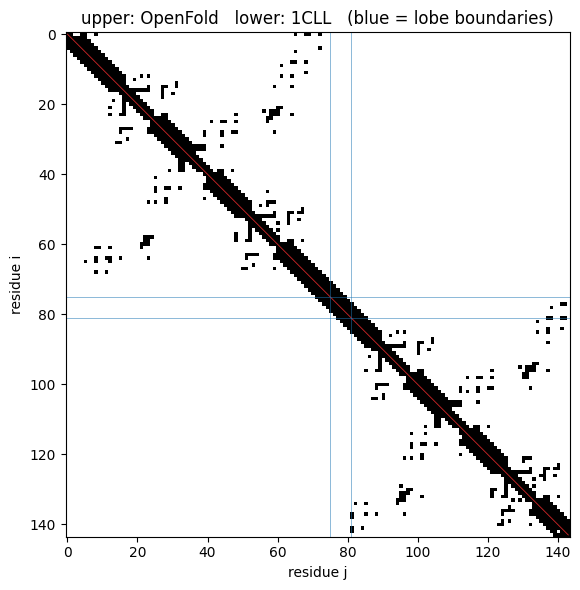

all contacts : precision 0.958  recall 0.990
long-range   : precision 0.828  recall 0.951  (186 predicted)
true long-range contacts: 162


In [9]:
def contact_map_from_coords(xyz, cutoff=8.0):
    d = np.linalg.norm(xyz[:, None, :] - xyz[None, :, :], axis=-1)
    return (d < cutoff).astype(float), d

pred_cm, pred_d = contact_map_from_coords(pred_cb[pi])
ref_cm,  ref_d  = contact_map_from_coords(ref_cb[ri])

n = len(common)
sep = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :])
lr = sep > 12

split = np.triu(pred_cm) + np.tril(ref_cm, -1)
fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.imshow(split, cmap="Greys", vmin=0, vmax=1, origin="upper", interpolation="nearest")
ax.plot([0, n-1], [0, n-1], lw=0.6, c="tab:red")
for b in [N_LOBE[1], C_LOBE[0]-1]:
    ax.axhline(b, c="tab:blue", lw=0.6, alpha=0.6); ax.axvline(b, c="tab:blue", lw=0.6, alpha=0.6)
ax.set_xlabel("residue j"); ax.set_ylabel("residue i")
ax.set_title(f"upper: OpenFold   lower: {PDB_ID}   (blue = lobe boundaries)")
plt.tight_layout(); plt.show()

def pr(cm, ref, mask):
    tp = ((cm==1)&(ref==1)&mask).sum(); fp = ((cm==1)&(ref==0)&mask).sum()
    fn = ((cm==0)&(ref==1)&mask).sum()
    return tp/max(tp+fp,1), tp/max(tp+fn,1), int(tp+fp)

p_all, r_all, _ = pr(pred_cm, ref_cm, np.ones_like(lr))
p_lr,  r_lr,  n_lr = pr(pred_cm, ref_cm, lr)
print(f"all contacts : precision {p_all:.3f}  recall {r_all:.3f}")
print(f"long-range   : precision {p_lr:.3f}  recall {r_lr:.3f}  ({n_lr} predicted)")
print(f"true long-range contacts: {int((ref_cm*lr).sum())}")

### Lobe masks

Three categories of long-range contact. The third is the one ubiquitin could not provide.

In [10]:
idx = common  # 1-based residue numbers, aligned to the matrices
in_n = (idx >= N_LOBE[0]) & (idx <= N_LOBE[1])
in_c = (idx >= C_LOBE[0]) & (idx <= C_LOBE[1])

MASK_NN    = np.outer(in_n, in_n) & lr          # within N-lobe
MASK_CC    = np.outer(in_c, in_c) & lr          # within C-lobe
MASK_INTER = (np.outer(in_n, in_c) | np.outer(in_c, in_n)) & lr   # between lobes

for nm, m in [("N-N", MASK_NN), ("C-C", MASK_CC), ("inter", MASK_INTER)]:
    t = int((ref_cm * m).sum())
    p, r, k = pr(pred_cm, ref_cm, m)
    print(f"{nm:6s} true {t:4d}   final precision {p:.3f}  recall {r:.3f}")

N-N    true   78   final precision 0.800  recall 0.923
C-C    true   84   final precision 0.932  recall 0.976
inter  true    0   final precision 0.000  recall 0.000


## 9. Capture the pair representation

Forward hooks on all 48 Evoformer blocks. Each block returns a tuple `(m, z)`; we keep
only `z`, the pair representation, and keep it on GPU.

The hooks fire once per block per recycle, in order, so a flat capture list reshapes to
`(n_rec, n_blk, L, L, c_z)`. The printed block order confirms that empirically rather than
by assumption — the boundary print should read `..., 46, 47, 0, 1, ...`.

At L=148 this is about 2.1 GB at fp32. If your GPU is tight, cast `z` to fp16 in the hook.

In [16]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [18]:
# nuke every forward hook on every block
for blk in model.evoformer.blocks:
    blk._forward_hooks.clear()

import gc
for v in ["Z", "captures", "pc_store", "ed_store", "PC", "ED"]:
    globals().pop(v, None)
gc.collect(); torch.cuda.empty_cache()
print(f"allocated {torch.cuda.memory_allocated()/1e9:.2f} GB  "
      f"reserved {torch.cuda.memory_reserved()/1e9:.2f} GB")

allocated 1.33 GB  reserved 3.20 GB


In [19]:
# free whatever's still held
for v in ["Z", "captures"]:
    if v in dir(): del globals()[v]
torch.cuda.empty_cache()

bins  = torch.linspace(2.3125, 21.6875, 63, device=device)
edges = torch.cat([bins, bins[-1:] + 0.3125])
CONTACT_BIN = int((8.0 - 2.3125) / 0.3125) + 1

pc_store, ed_store = [], []

def make_hook(i):
    def hook(module, args, output):
        z = output[1]
        with torch.no_grad():
            p = model.aux_heads.distogram(z).softmax(-1)
            p = (p + p.transpose(0, 1)) / 2
            pc_store.append((i, p[..., :CONTACT_BIN].sum(-1).cpu()))
            ed_store.append((i, (p * edges).sum(-1).cpu()))
    return hook

handles = [blk.register_forward_hook(make_hook(i))
           for i, blk in enumerate(model.evoformer.blocks)]
pc_store.clear(); ed_store.clear()
with torch.no_grad():
    _ = model(batch)
for h in handles: h.remove()

assert [b for b, _ in pc_store[N_BLK-2:N_BLK+2]] == [N_BLK-2, N_BLK-1, 0, 1]
PC = torch.stack([t for _, t in pc_store]).reshape(N_REC, N_BLK, L, L).numpy()
ED = torch.stack([t for _, t in ed_store]).reshape(N_REC, N_BLK, L, L).numpy()
del pc_store, ed_store
torch.cuda.empty_cache()
print(PC.shape, f"{PC.nbytes/1e6:.1f} MB on CPU")

(4, 48, 148, 148) 16.8 MB on CPU


### Validate the head against the model's own output

**Do not skip this.** It confirms that applying `model.aux_heads.distogram` to a captured
`z` reproduces exactly what the model produced, which is what licenses applying the same
head at every intermediate block. On ubiquitin this came back 0.0.

If it is not ~0, something sits between the last block and the head and every intermediate
readout is systematically wrong.

In [21]:
# what the model itself reported, reduced the same way
p_ref = torch.as_tensor(out["distogram_logits"]).softmax(-1)
p_ref = (p_ref + p_ref.transpose(0, 1)) / 2
pc_ref = p_ref[..., :CONTACT_BIN].sum(-1).numpy()
ed_ref = (p_ref * edges.cpu()).sum(-1).numpy()

print("P(contact) max abs diff:", np.abs(PC[-1, -1] - pc_ref).max())
print("E[d]       max abs diff:", np.abs(ED[-1, -1] - ed_ref).max())
assert np.abs(PC[-1, -1] - pc_ref).max() < 1e-4, \
    "captured readout does not match model output — intermediates invalid"
print("bins below 8 A:", CONTACT_BIN, "-> upper edge", float(bins[CONTACT_BIN-1]))

P(contact) max abs diff: 4.172325e-07
E[d]       max abs diff: 7.6293945e-06
bins below 8 A: 19 -> upper edge 7.9375


### The contact readout

Probability mass below 8 A, symmetrized. **Not** `E[d] < 8` — the 64th catch-all bin
absorbs every distance past 22 A, which drags the expectation upward and systematically
under-predicts contacts.

In [23]:
# PC/ED are indexed over all L residues; the reference is indexed over `common`.
# Slice down to the matched residues so the masks line up.
ZI = np.searchsorted(np.arange(1, L + 1), common)

def readout(rr, bb, thresh=0.5):
    """(binary contact map, continuous P(contact)) at recycle rr, block bb — matched residues."""
    pc = PC[rr, bb][np.ix_(ZI, ZI)]
    return (pc > thresh).astype(float), pc

def exp_dist(rr, bb):
    """Expected Cb-Cb distance (A) at recycle rr, block bb — matched residues."""
    return ED[rr, bb][np.ix_(ZI, ZI)]

cm48, _ = readout(N_REC - 1, N_BLK - 1)
p, r, k = pr(cm48, ref_cm, lr)
print(f"block {N_BLK}, recycle {N_REC}: precision {p:.3f}  recall {r:.3f}  n {k}")
print("compare to the coordinate-based numbers in section 8 — they should be close")

block 48, recycle 4: precision 0.893  recall 0.827  n 150
compare to the coordinate-based numbers in section 8 — they should be close


## 10. Finding 1 — what does the model know at block 1?

On ubiquitin, recycle 1 / block 1 gave 8 long-range contacts, all correct, separations up
to 38. Recycle 1 matters because there is no prior pass to inherit an answer from.

The lobe label on each contact is the new information here.

In [25]:
def lobe_of(i_resnum, j_resnum):
    a = "N" if i_resnum <= N_LOBE[1] else ("L" if i_resnum < C_LOBE[0] else "C")
    b = "N" if j_resnum <= N_LOBE[1] else ("L" if j_resnum < C_LOBE[0] else "C")
    return "".join(sorted([a, b]))

for r_idx, label in [(0, "recycle 1"), (N_REC - 1, f"recycle {N_REC}")]:
    cm, _ = readout(r_idx, 0)
    ii, jj = np.where((cm == 1) & lr)
    print(f"\n--- block 1, {label} ---")
    shown = set()
    for a, b in zip(ii, jj):
        if a >= b or (a, b) in shown: continue
        shown.add((a, b))
        ra, rb = int(common[a]), int(common[b])
        ok = "OK " if ref_cm[a, b] == 1 else "MISS"
        print(f"  ({ra:3d},{rb:3d})  sep {rb-ra:3d}  {lobe_of(ra,rb):2s}  "
              f"true {ref_d[a,b]:5.1f} A  {ok}")
    if not shown:
        print("  none")
    else:
        tp = sum(1 for a, b in shown if ref_cm[a, b] == 1)
        print(f"  {tp}/{len(shown)} correct")


--- block 1, recycle 1 ---
  (  9, 69)  sep  60  NN  true   7.5 A  OK 
  ( 10, 74)  sep  64  NN  true  19.4 A  MISS
  ( 12, 72)  sep  60  NN  true   5.9 A  OK 
  ( 21, 34)  sep  13  NN  true   6.5 A  OK 
  ( 24, 62)  sep  38  NN  true   9.0 A  MISS
  ( 26, 62)  sep  36  NN  true   3.9 A  OK 
  ( 26, 64)  sep  38  NN  true   5.3 A  OK 
  ( 57, 74)  sep  17  NN  true  11.7 A  MISS
  ( 73, 91)  sep  18  CN  true  28.5 A  MISS
  ( 86,138)  sep  52  CC  true   7.4 A  OK 
  ( 86,139)  sep  53  CC  true  11.8 A  MISS
  ( 86,146)  sep  60  CC  true  12.5 A  MISS
  ( 91,108)  sep  17  CC  true   6.8 A  OK 
  ( 91,111)  sep  20  CC  true   9.6 A  MISS
  ( 92,108)  sep  16  CC  true   5.6 A  OK 
  ( 94,107)  sep  13  CC  true   6.8 A  OK 
  ( 99,135)  sep  36  CC  true   3.9 A  OK 
  (101,135)  sep  34  CC  true   5.5 A  OK 
  (102,121)  sep  19  CC  true   5.0 A  OK 
  (102,122)  sep  20  CC  true   5.9 A  OK 
  (106,122)  sep  16  CC  true   9.4 A  MISS
  (130,146)  sep  16  CC  true  14.0 A  

## 11. Findings 2, 3, 5 — precision, recall and oscillation by block

Three panels of the same sweep:

- **Left, continuous** — mean P(contact) over true contacts. Oscillation *here* is the
  model's actual belief moving, not a thresholding artifact
- **Middle** — mean P(contact) over non-contacts. On ubiquitin this stayed under 0.01 the
  whole way, which is why precision was flat near 1.0: the model essentially never assigns
  probability to wrong pairs
- **Right, thresholded** — what a recall curve plots

The printed residual-std ratio quantifies how much thresholding contributes. On ubiquitin
it was 1.0x, meaning nothing.

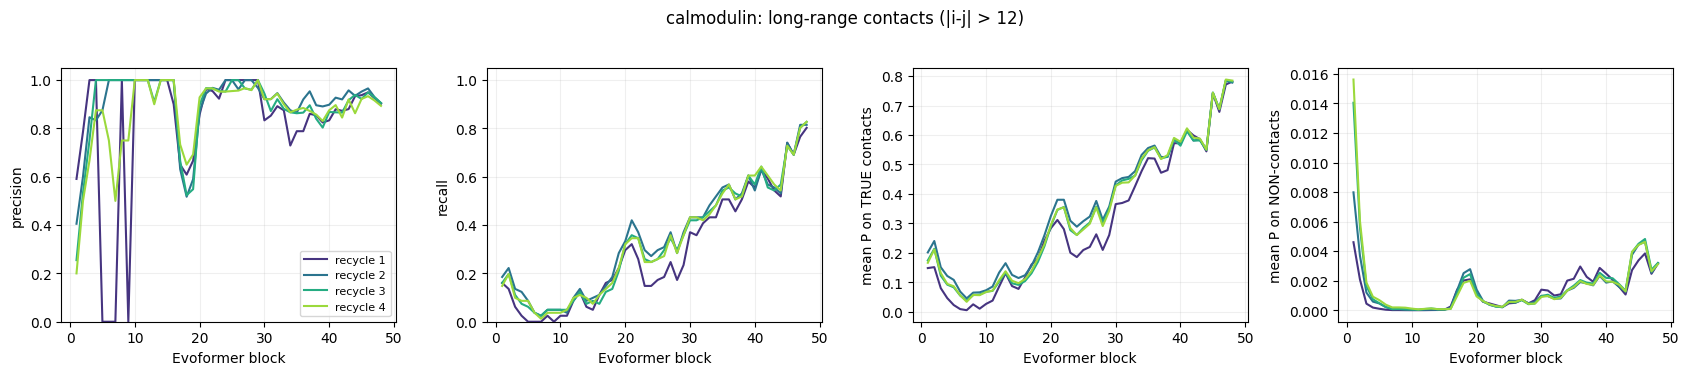

residual std, continuous : 0.0403
residual std, thresholded: 0.0449   ratio 1.1x

final: precision 0.893  recall 0.827  n 150
block 1 recycle 1: precision 0.591  recall 0.160  n 44


In [37]:
true_lr, false_lr = (ref_cm == 1) & lr, (ref_cm == 0) & lr
prec = np.zeros((N_REC, N_BLK)); recl = np.zeros((N_REC, N_BLK))
npred = np.zeros((N_REC, N_BLK), dtype=int)
pc_true = np.zeros((N_REC, N_BLK)); pc_false = np.zeros((N_REC, N_BLK))

for rr in range(N_REC):
    for bb in range(N_BLK):
        cm, pc = readout(rr, bb)
        tp = ((cm==1)&(ref_cm==1)&lr).sum(); fp = ((cm==1)&(ref_cm==0)&lr).sum()
        fn = ((cm==0)&(ref_cm==1)&lr).sum()
        prec[rr,bb] = tp/max(tp+fp,1); recl[rr,bb] = tp/max(tp+fn,1)
        npred[rr,bb] = tp+fp
        pc_true[rr,bb] = pc[true_lr].mean(); pc_false[rr,bb] = pc[false_lr].mean()

# consistency guard: precision*npred and recall*n_true must agree on TP
n_true_lr = int((ref_cm*lr).sum())
assert abs(prec[-1,-1]*npred[-1,-1] - recl[-1,-1]*n_true_lr) < 2, "stale variables — rerun in order"

x = np.arange(1, N_BLK+1)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, N_REC))
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6), sharex=True)
for rr in range(N_REC):
    axes[0].plot(x, prec[rr],     color=colors[rr], lw=1.5, label=f"recycle {rr+1}")
    axes[1].plot(x, recl[rr],     color=colors[rr], lw=1.5)
    axes[2].plot(x, pc_true[rr],  color=colors[rr], lw=1.5)
    axes[3].plot(x, pc_false[rr], color=colors[rr], lw=1.5)
axes[0].set_ylabel("precision"); axes[0].set_ylim(0,1.05); axes[0].legend(fontsize=8)
axes[1].set_ylabel("recall");    axes[1].set_ylim(0,1.05)
axes[2].set_ylabel("mean P on TRUE contacts")
axes[3].set_ylabel("mean P on NON-contacts")
for ax in axes: ax.set_xlabel("Evoformer block"); ax.grid(alpha=0.2)
fig.suptitle(f"{NAME}: long-range contacts (|i-j| > 12)", y=1.03)
plt.tight_layout(); plt.show()

from numpy.polynomial import polynomial as P
def wiggle(s, deg=6):
    resid = s - P.polyval(x, P.polyfit(x, s, deg)); return resid, resid.std()
r_cont, s_cont = wiggle(pc_true[-1])
r_thr,  s_thr  = wiggle((prec[-1]*npred[-1])/max(n_true_lr,1))
print(f"residual std, continuous : {s_cont:.4f}")
print(f"residual std, thresholded: {s_thr:.4f}   ratio {s_thr/max(s_cont,1e-9):.1f}x")
print(f"\nfinal: precision {prec[-1,-1]:.3f}  recall {recl[-1,-1]:.3f}  n {npred[-1,-1]}")
print(f"block 1 recycle 1: precision {prec[0,0]:.3f}  recall {recl[0,0]:.3f}  n {npred[0,0]}")

### Is the oscillation phase-locked across proteins?

The ubiquitin FFT peaked around 16 blocks with a secondary near 9-10 — but on 48 samples
that is only three cycles, so treat the peak position as approximate.

**The real test is whether calmodulin oscillates at the same block indices.** Same phase
implies the oscillation is a property of the architecture. Different phase implies it is
protein-specific. The cell saves the curve so the two can be compared directly.

saved /home/caitlinlewis/repos/mech-interp-sandbox/alpha-fold/work/curves/calmodulin_curves.npz

ubiquitin_curves.npz not found — save it from the ubiquitin notebook to overlay


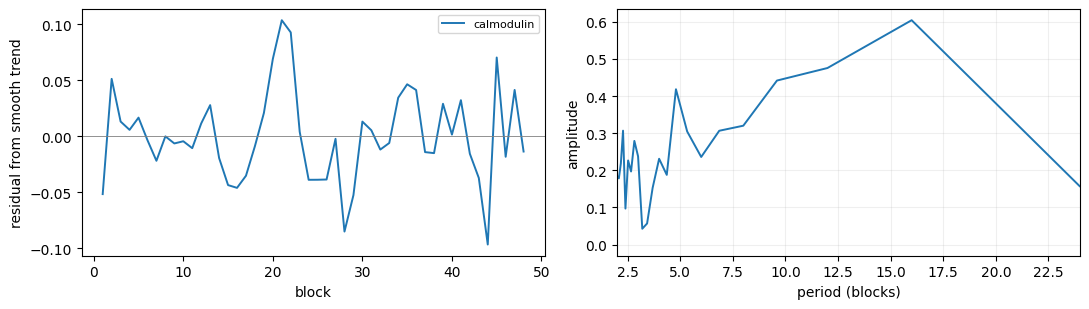

In [38]:
np.savez(WORK / "curves" / f"{NAME}_curves.npz",
         prec=prec, recl=recl, npred=npred, pc_true=pc_true, pc_false=pc_false,
         L=L, msa_depth=MSA_DEPTH, n_true_lr=n_true_lr)
print("saved", WORK / "curves" / f"{NAME}_curves.npz")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(x, r_cont, lw=1.4, label=f"{NAME}")
ax[0].axhline(0, c="gray", lw=0.6)
ax[0].set_xlabel("block"); ax[0].set_ylabel("residual from smooth trend")

f = np.fft.rfftfreq(len(r_cont), d=1.0)
amp = np.abs(np.fft.rfft(r_cont - r_cont.mean()))
ax[1].plot(1/np.maximum(f, 1e-9), amp, lw=1.4)
ax[1].set_xlim(2, 24); ax[1].set_xlabel("period (blocks)"); ax[1].set_ylabel("amplitude")
ax[1].grid(alpha=0.2)

# overlay ubiquitin if its curves were saved
ubq = WORK / "curves" / "ubiquitin_curves.npz"
if ubq.exists():
    d = np.load(ubq)
    r_cont, s_cont = wiggle(pc_true[-1])
    ax[0].plot(x, r_cont, lw=1.4, alpha=0.75, label="ubiquitin")
    amp_u = np.abs(np.fft.rfft(r_u - r_u.mean()))
    ax[1].plot(1/np.maximum(f, 1e-9), amp_u, lw=1.4, alpha=0.75)
    print(f"\ncorrelation of residuals across proteins: {np.corrcoef(r_cont, r_u)[0,1]:.3f}")
    print("high correlation -> oscillation is architectural, not protein-specific")
else:
    print("\nubiquitin_curves.npz not found — save it from the ubiquitin notebook to overlay")
ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 12. The new question — do the lobes commit on different schedules?

Same sweep, split three ways. The hypothesis worth testing:

- **Intra-lobe contacts** commit early, like ubiquitin's
- **Inter-lobe contacts** commit late, or never

If that holds, the commitment story maps directly onto PAE: the bright off-diagonal PAE
block is the model reporting that it never committed to the inter-lobe arrangement. That
is a much stronger claim than either finding alone, because it connects an internal
dynamic to a user-visible output.

Note inter-lobe contacts may simply be rare in calmodulin's extended conformation — check
the counts printed in section 8 before reading much into a noisy inter-lobe curve.

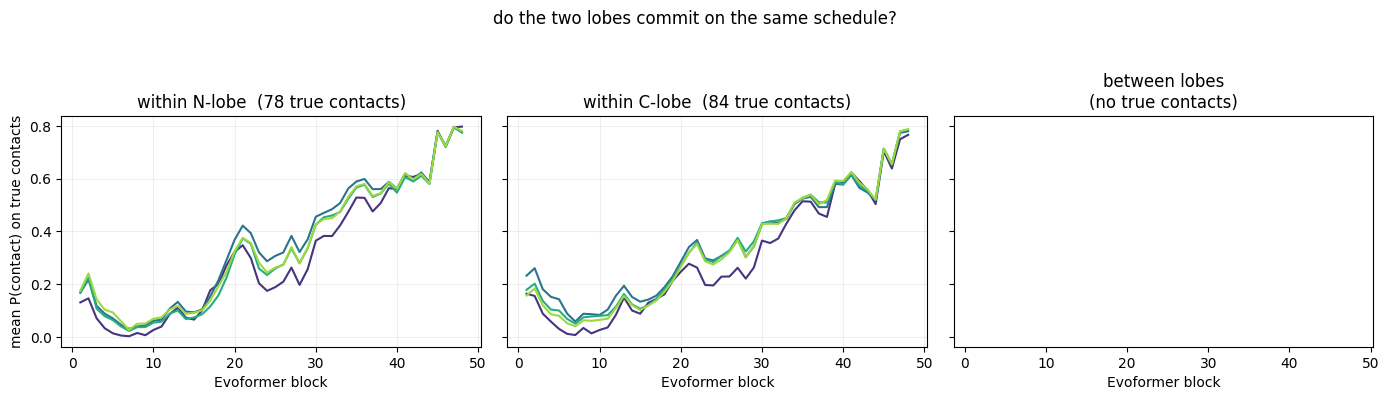

In [36]:
groups = [("within N-lobe", MASK_NN), ("within C-lobe", MASK_CC), ("between lobes", MASK_INTER)]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True)

for ax, (nm, m) in zip(axes, groups):
    sel = (ref_cm == 1) & m
    n_t = int(sel.sum())
    if n_t == 0:
        ax.set_title(f"{nm}\n(no true contacts)")
        ax.set_xlabel("Evoformer block")
        continue
    for rr in range(N_REC):
        curve = np.array([readout(rr, bb)[1][sel].mean() for bb in range(N_BLK)])
        ax.plot(x, curve, color=colors[rr], lw=1.5)
    ax.set_title(f"{nm}  ({n_t} true contacts)")
    ax.set_xlabel("Evoformer block"); ax.grid(alpha=0.2)

axes[0].set_ylabel("mean P(contact) on true contacts")
fig.suptitle("do the two lobes commit on the same schedule?", y=1.04)
plt.tight_layout(); plt.show()

## 13. Finding 4 — commitment order

For every true long-range contact, the first global step `(recycle x 48 + block)` at which
it is predicted. Two views:

- **Left**: that step painted onto the contact map. Grey = never predicted; red circles
  mark true contacts the model never found
- **Right**: commitment step against sequence separation. On ubiquitin this was flat —
  the model does *not* work outward from local structure. Lobe boundaries are marked so
  you can see whether inter-lobe contacts sit high

The earliest-commitment listing at the end is the raw material for the post's opening.

142 / 162 true long-range contacts ever predicted (88%)
distinct commitment steps: 27


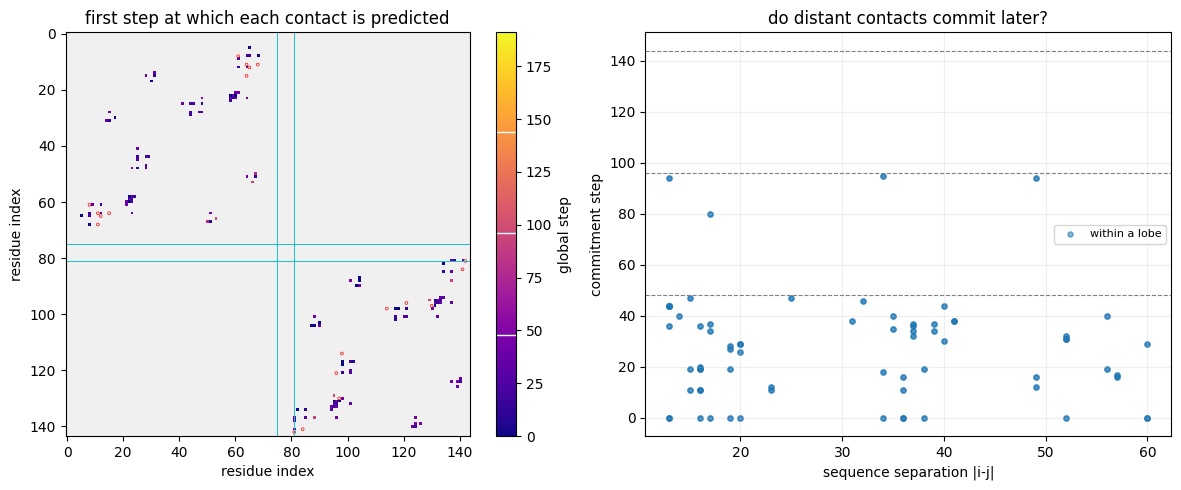


earliest commitments:
  (  9, 69)  sep  60  NN  step   0 (recycle 1, block 1)  true 7.5 A
  (102,122)  sep  20  CC  step   0 (recycle 1, block 1)  true 5.9 A
  (102,121)  sep  19  CC  step   0 (recycle 1, block 1)  true 5.0 A
  (101,135)  sep  34  CC  step   0 (recycle 1, block 1)  true 5.5 A
  ( 99,135)  sep  36  CC  step   0 (recycle 1, block 1)  true 3.9 A
  ( 94,107)  sep  13  CC  step   0 (recycle 1, block 1)  true 6.8 A
  ( 92,108)  sep  16  CC  step   0 (recycle 1, block 1)  true 5.6 A
  ( 91,108)  sep  17  CC  step   0 (recycle 1, block 1)  true 6.8 A
  ( 86,138)  sep  52  CC  step   0 (recycle 1, block 1)  true 7.4 A
  ( 26, 62)  sep  36  NN  step   0 (recycle 1, block 1)  true 3.9 A
  ( 12, 72)  sep  60  NN  step   0 (recycle 1, block 1)  true 5.9 A
  ( 26, 64)  sep  38  NN  step   0 (recycle 1, block 1)  true 5.3 A


In [35]:
commit = np.full((n, n), np.nan)
for rr in range(N_REC):
    for bb in range(N_BLK):
        cm, _ = readout(rr, bb)
        newly = (cm == 1) & (ref_cm == 1) & lr & np.isnan(commit)
        commit[newly] = rr * N_BLK + bb

n_found = int(np.sum(~np.isnan(commit)))
print(f"{n_found} / {n_true_lr} true long-range contacts ever predicted "
      f"({100*n_found/max(n_true_lr,1):.0f}%)")
print("distinct commitment steps:", len(np.unique(commit[~np.isnan(commit)])))
assert len(np.unique(commit[~np.isnan(commit)])) > 1, "loop not running — check readout"

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
cmap = plt.cm.plasma.copy(); cmap.set_bad("#f0f0f0")
im = axes[0].imshow(np.ma.masked_invalid(commit), cmap=cmap,
                    vmin=0, vmax=N_REC*N_BLK-1, interpolation="nearest", origin="upper")
ni, nj = np.where(true_lr & np.isnan(commit))
axes[0].scatter(nj, ni, s=4, facecolors="none", edgecolors="red", lw=0.5)
for b in [N_LOBE[1], C_LOBE[0]-1]:
    axes[0].axhline(b, c="tab:cyan", lw=0.7); axes[0].axvline(b, c="tab:cyan", lw=0.7)
axes[0].set_xlabel("residue index"); axes[0].set_ylabel("residue index")
axes[0].set_title("first step at which each contact is predicted")
cb = fig.colorbar(im, ax=axes[0], fraction=0.046); cb.set_label("global step")
for rr in range(1, N_REC): cb.ax.axhline(rr*N_BLK, c="white", lw=1)

ci, cj = np.where(~np.isnan(commit))
grp = np.where(MASK_INTER[ci, cj], "between lobes", "within a lobe")
for g, mk in [("within a lobe", "o"), ("between lobes", "^")]:
    sel = grp == g
    if sel.sum():
        axes[1].scatter(np.abs(ci-cj)[sel], commit[ci, cj][sel], s=14, alpha=0.55,
                        marker=mk, label=g)
for rr in range(1, N_REC): axes[1].axhline(rr*N_BLK, ls="--", lw=0.8, c="gray")
axes[1].set_xlabel("sequence separation |i-j|"); axes[1].set_ylabel("commitment step")
axes[1].set_title("do distant contacts commit later?"); axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()

print("\nearliest commitments:")
seen = set()
for k in np.argsort(commit[ci, cj]):
    a, b = ci[k], cj[k]
    if a > b or (a, b) in seen: continue
    seen.add((a, b))
    s = int(commit[a, b]); ra, rb = int(common[a]), int(common[b])
    print(f"  ({ra:3d},{rb:3d})  sep {rb-ra:3d}  {lobe_of(ra,rb):2s}  step {s:3d} "
          f"(recycle {s//N_BLK+1}, block {s%N_BLK+1})  true {ref_d[a,b]:.1f} A")
    if len(seen) >= 12: break

In [39]:
for bb in range(3, 14):
    print(f"block {bb+1:2d}  n_pred {npred[-1,bb]:4d}  prec {prec[-1,bb]:.3f}  recall {recl[-1,bb]:.3f}")

block  4  n_pred   16  prec 0.875  recall 0.086
block  5  n_pred   16  prec 0.875  recall 0.086
block  6  n_pred    8  prec 0.750  recall 0.037
block  7  n_pred    4  prec 0.500  recall 0.012
block  8  n_pred    8  prec 0.750  recall 0.037
block  9  n_pred    8  prec 0.750  recall 0.037
block 10  n_pred    6  prec 1.000  recall 0.037
block 11  n_pred    8  prec 1.000  recall 0.049
block 12  n_pred   16  prec 1.000  recall 0.099
block 13  n_pred   20  prec 0.900  recall 0.111
block 14  n_pred   16  prec 1.000  recall 0.099


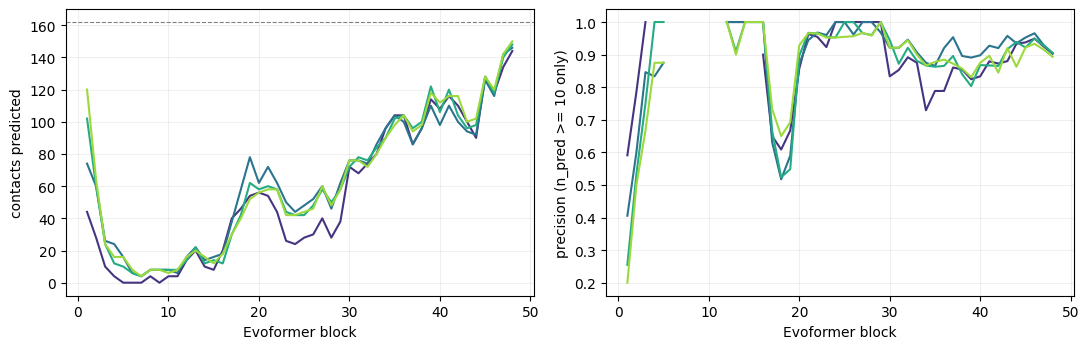

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for rr in range(N_REC):
    ax[0].plot(x, npred[rr], color=colors[rr], lw=1.5)
    p = prec[rr].copy(); p[npred[rr] < 10] = np.nan
    ax[1].plot(x, p, color=colors[rr], lw=1.5)
ax[0].axhline(n_true_lr, ls="--", lw=0.8, c="gray")
ax[0].set_ylabel("contacts predicted"); ax[1].set_ylabel("precision (n_pred >= 10 only)")
for a in ax: a.set_xlabel("Evoformer block"); a.grid(alpha=0.2)
plt.tight_layout(); plt.show()

In [41]:
cm1, _ = readout(0, 0); cm12, _ = readout(0, 11)
s1 = {(a,b) for a,b in zip(*np.where((cm1==1)&lr)) if a<b}
s12 = {(a,b) for a,b in zip(*np.where((cm12==1)&lr)) if a<b}
print(f"block 1: {len(s1)}  block 12: {len(s12)}  overlap: {len(s1&s12)}")

block 1: 22  block 12: 7  overlap: 2


In [42]:
_, pc1 = readout(0, 0)
surv = s1 & s12
print("survivors:")
for a, b in sorted(s1, key=lambda ab: -pc1[ab]):
    tag = "SURVIVES" if (a,b) in surv else ""
    ok = "OK" if ref_cm[a,b]==1 else "wrong"
    print(f"  ({int(common[a]):3d},{int(common[b]):3d})  P {pc1[a,b]:.3f}  "
          f"true {ref_d[a,b]:5.1f}A  {ok:5s} {tag}")

survivors:
  ( 99,135)  P 0.998  true   3.9A  OK    SURVIVES
  (101,135)  P 0.985  true   5.5A  OK    
  ( 26, 62)  P 0.951  true   3.9A  OK    SURVIVES
  ( 86,138)  P 0.908  true   7.4A  OK    
  ( 24, 62)  P 0.889  true   9.0A  wrong 
  ( 94,107)  P 0.876  true   6.8A  OK    
  ( 12, 72)  P 0.828  true   5.9A  OK    
  ( 86,146)  P 0.816  true  12.5A  wrong 
  ( 21, 34)  P 0.804  true   6.5A  OK    
  (130,146)  P 0.778  true  14.0A  wrong 
  (  9, 69)  P 0.701  true   7.5A  OK    
  ( 91,108)  P 0.697  true   6.8A  OK    
  ( 26, 64)  P 0.682  true   5.3A  OK    
  ( 91,111)  P 0.653  true   9.6A  wrong 
  ( 86,139)  P 0.634  true  11.8A  wrong 
  (102,121)  P 0.620  true   5.0A  OK    
  (106,122)  P 0.612  true   9.4A  wrong 
  ( 10, 74)  P 0.608  true  19.4A  wrong 
  (102,122)  P 0.559  true   5.9A  OK    
  ( 73, 91)  P 0.551  true  28.5A  wrong 
  ( 92,108)  P 0.520  true   5.6A  OK    
  ( 57, 74)  P 0.502  true  11.7A  wrong 


In [43]:
for cut in [8, 10, 12, 15]:
    tp = sum(1 for a,b in s1 if ref_d[a,b] < cut)
    print(f"block 1 predictions within {cut:2d} A: {tp}/{len(s1)} = {tp/len(s1):.2f}")

block 1 predictions within  8 A: 13/22 = 0.59
block 1 predictions within 10 A: 16/22 = 0.73
block 1 predictions within 12 A: 18/22 = 0.82
block 1 predictions within 15 A: 20/22 = 0.91


## 14. Scorecard

Fill this in from the cells above and keep it — it is the table the post needs, and the
place where "does this generalize" gets answered honestly.

| # | Finding | Ubiquitin | Calmodulin |
|---|---|---|---|
| 1 | correct long-range contacts at block 1, recycle 1 | 8, all correct, sep to 38 | |
| 2 | precision flat near 1.0 while recall climbs | 1.000 to 0.945; recall 0.03 to 0.95 | |
| 3 | oscillation present, ratio thresh/cont | yes, 1.0x | |
| 4 | commitment step vs separation | flat | |
| 5 | recycling effect | negligible | |
| 6 | inter-domain commitment | n/a (single domain) | |

### Honest caveats for the post

- Two proteins, one model (`model_3_ptm`), one seed. Both have deep MSAs and are
  unusually well predicted. **A protein with a shallow alignment is the real test** —
  if early commitment only happens on easy targets, that is the actual finding
- Applying the distogram head at intermediate blocks is off-distribution; the head was
  trained only on block 48. The block-48 validation in section 9 shows the head is exact
  where it was trained, not that intermediate readouts are calibrated
- 1CLL is the calcium-bound extended crystal form. Calmodulin is genuinely flexible, so
  linker disagreement is not necessarily error
- Lobe boundaries here are approximate and hand-set

### Next

If findings 1-4 hold on both, run a shallow-MSA target before writing. If they diverge,
that divergence is more interesting than the original result and should lead the post.